## SOAL 1

In [3]:
import threading

# ==========================================
# 1. SIMULASI TANPA LOCK (RACE CONDITION)
# ==========================================
saldo_tanpa_lock = 1_000_000

def transaksi_tanpa_lock():
    global saldo_tanpa_lock
    for _ in range(10_000):
        # Operasi "tarik 1 lalu setor 1"
        saldo_tanpa_lock -= 1
        saldo_tanpa_lock += 1

threads_tanpa_lock = []
for _ in range(10):
    t = threading.Thread(target=transaksi_tanpa_lock)
    threads_tanpa_lock.append(t)
    t.start()

for t in threads_tanpa_lock:
    t.join()

print(f"Saldo Akhir (Tanpa Lock) : {saldo_tanpa_lock}")


# ==========================================
# 2. SIMULASI DENGAN LOCK (THREAD-SAFE)
# ==========================================
saldo_dengan_lock = 1_000_000
lock = threading.Lock()

def transaksi_dengan_lock():
    global saldo_dengan_lock
    for _ in range(10_000):
        # Menggunakan 'with lock' untuk mengunci critical section
        with lock:
            saldo_dengan_lock -= 1
            saldo_dengan_lock += 1

threads_dengan_lock = []
for _ in range(10):
    t = threading.Thread(target=transaksi_dengan_lock)
    threads_dengan_lock.append(t)
    t.start()

for t in threads_dengan_lock:
    t.join()

print(f"Saldo Akhir (Dengan Lock): {saldo_dengan_lock}")

Saldo Akhir (Tanpa Lock) : 1000000
Saldo Akhir (Dengan Lock): 1000000


1. Mengapa Tanpa Lock Gagal?
>Operasi saldo -= 1 di Python terdiri dari 3 langkah: Baca $\rightarrow$ Ubah $\rightarrow$ Simpan. Tanpa lock, thread B bisa membaca saldo lama sebelum thread A sempat menyimpan hasil perubahannya, sehingga transaksi thread A hilang (lost update).

2. Mengapa Lock() Berhasil?
>Blok with lock: menerapkan Mutual Exclusion (penguncian). Kunci ini memaksa thread lain untuk antre sampai thread yang sedang memegang kunci selesai melakukan operasi Baca $\rightarrow$ Ubah $\rightarrow$ Simpan, sehingga saldo akhir dijamin tetap 1.000.000.

## SOAL 2

In [4]:
import queue
import random
import threading
import time

# Inisialisasi Queue dan Jumlah Consumer
q = queue.Queue()
NUM_CONSUMERS = 3


def producer(q, total_items):
    print("[Producer] Mulai memproduksi tugas...")
    for i in range(1, total_items + 1):
        item = f"Tugas-{i}"
        q.put(item)
        print(f"[Producer] Menambahkan: {item}")
        time.sleep(random.uniform(0.1, 0.2))

    # Mengirim sinyal None sebanyak jumlah Consumer
    print("\n[Producer] Selesai memproduksi. Mengirim sinyal None ke semua consumer...\n")
    for _ in range(NUM_CONSUMERS):
        q.put(None)


def consumer(q, consumer_id):
    print(f"  [Consumer-{consumer_id}] Siap menerima tugas.")
    while True:
        item = q.get()

        # Cek sinyal berhenti (Poison Pill)
        if item is None:
            q.task_done()
            print(f"  [Consumer-{consumer_id}] Menerima sinyal None -> Berhenti.")
            break

        # Simulasi pemrosesan tugas
        print(f"  [Consumer-{consumer_id}] Sedang memproses {item}...")
        time.sleep(random.uniform(0.3, 0.5))
        print(f"  [Consumer-{consumer_id}] Selesai memproses {item}")
        q.task_done()


# Jumlah tugas yang diproduksi
TOTAL_TUGAS = 9

# Membuat thread Producer
t_producer = threading.Thread(target=producer, args=(q, TOTAL_TUGAS))

# Membuat 3 thread Consumer
threads_consumer = []
for i in range(1, NUM_CONSUMERS + 1):
    t = threading.Thread(target=consumer, args=(q, i))
    threads_consumer.append(t)

# Menjalankan thread
t_producer.start()
for t in threads_consumer:
    t.start()

# Menunggu seluruh thread selesai
t_producer.join()
for t in threads_consumer:
    t.join()

print("\n[Selesai] Semua tugas telah diproses dan seluruh consumer berhenti dengan baik.")

[Producer] Mulai memproduksi tugas...  [Consumer-1] Siap menerima tugas.

[Producer] Menambahkan: Tugas-1
  [Consumer-1] Sedang memproses Tugas-1...
  [Consumer-2] Siap menerima tugas.
  [Consumer-3] Siap menerima tugas.
[Producer] Menambahkan: Tugas-2
  [Consumer-2] Sedang memproses Tugas-2...
[Producer] Menambahkan: Tugas-3  [Consumer-3] Sedang memproses Tugas-3...

[Producer] Menambahkan: Tugas-4
  [Consumer-1] Selesai memproses Tugas-1
  [Consumer-1] Sedang memproses Tugas-4...
  [Consumer-2] Selesai memproses Tugas-2
[Producer] Menambahkan: Tugas-5
  [Consumer-2] Sedang memproses Tugas-5...
  [Consumer-3] Selesai memproses Tugas-3
[Producer] Menambahkan: Tugas-6  [Consumer-3] Sedang memproses Tugas-6...

[Producer] Menambahkan: Tugas-7
  [Consumer-1] Selesai memproses Tugas-4
  [Consumer-1] Sedang memproses Tugas-7...
  [Consumer-2] Selesai memproses Tugas-5
[Producer] Menambahkan: Tugas-8
  [Consumer-2] Sedang memproses Tugas-8...
  [Consumer-3] Selesai memproses Tugas-6
[Produce

## SOAL 3

=== MEMULAI EKSPERIMEN THREADPOOLEXECUTOR ===
max_workers =  2 | Waktu Eksekusi: 2.5172 detik
max_workers =  4 | Waktu Eksekusi: 1.3097 detik
max_workers =  8 | Waktu Eksekusi: 0.7067 detik
max_workers = 16 | Waktu Eksekusi: 0.4045 detik


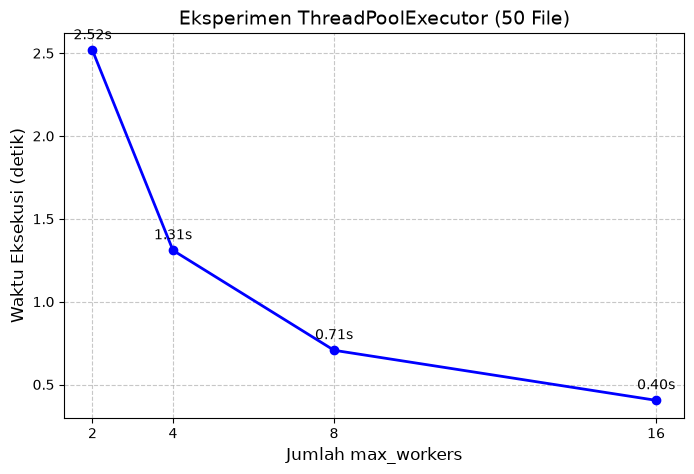

In [5]:
from concurrent.futures import ThreadPoolExecutor
import time
import random
import matplotlib.pyplot as plt

# Simulasi fungsi pengunduhan file (I/O-bound)
def download_file(file_id):
    # Simulasi waktu tunggu download 0.1 detik per file
    time.sleep(0.1)
    return f"File {file_id} selesai"

NUM_FILES = 50
worker_counts = [2, 4, 8, 16]
execution_times = []

print("=== MEMULAI EKSPERIMEN THREADPOOLEXECUTOR ===")

for workers in worker_counts:
    start_time = time.perf_counter()
    
    # Menggunakan ThreadPoolExecutor dengan max_workers bervariasi
    with ThreadPoolExecutor(max_workers=workers) as executor:
        # Menjalankan 50 tugas download
        results = list(executor.map(download_file, range(1, NUM_FILES + 1)))
        
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    
    print(f"max_workers = {workers:2d} | Waktu Eksekusi: {elapsed_time:.4f} detik")

# ==========================================
# PLOTTING WAKTU EKSEKUSI VS MAX_WORKERS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(worker_counts, execution_times, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Eksperimen ThreadPoolExecutor (50 File)', fontsize=14)
plt.xlabel('Jumlah max_workers', fontsize=12)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.xticks(worker_counts)
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan nilai waktu di setiap titik plot
for x, y in zip(worker_counts, execution_times):
    plt.annotate(f"{y:.2f}s", (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.show()

1. Apakah menambah max_workers terus-menerus selalu mempercepat proses?
>Tidak. Menambah max_workers hanya akan mempercepat proses hingga batas tertentu. Setelah melewati batas optimal tersebut, penambahan workers tidak lagi memberikan peningkatan kecepatan yang signifikan dan grafik akan mulai melandai (mencapai titik jenuh / plateau).

2. Mengapa terjadi Titik Jenuh (Saturation Point / Diminishing Returns)?
> Batas Hardware & Bandwidth Jaringan (I/O Bottleneck) : Pada kasus pengunduhan file nyata, kecepatan total dibatasi oleh lebar pita (bandwidth) koneksi internet dan kecepatan tulis media penyimpanan (disk I/O). Ketika kapasitas bandwidth sudah terpakai $100\%$, menambah jumlah thread pengunduh tidak akan menambah kecepatan download.

>Overhead Context Switching & Memori : Setiap thread membutuhkan alokasi memori sistem dan memerlukan overhead CPU untuk mengelola pergantian antar-thread (context switching). Jika jumlah thread terlalu banyak, CPU akan menghabiskan lebih banyak daya untuk mengelola thread daripada menyelesaikan tugas utama.

>Batasan GIL (Global Interpreter Lock): Meskipun tugas I/O-bound melepas kunci GIL saat menunggu jaringan/disk, eksekusi kode Python-nya sendiri (seperti membuat thread, scheduling, dan mengembalikan future objects) tetap berjalan secara bergantian di bawah GIL.


## SOAL 4

Berikan satu contoh kasus nyata (di luar contoh pada notebook ini) di mana threading Python akan membantu, dan satu contoh kasus di mana threading Python tidak akan membantu dan sebaiknya menunggu materi multiprocessing
>Aplikasi bot pemantau harga e-commerce yang mengirim permintaan HTTP ke puluhan server toko online secara bersamaan. Threading sangat efektif karena sebagian besar waktu dihabiskan untuk menunggu respons jaringan (network latency), sehingga Python melepaskan kunci GIL dan memungkinkan thread lain berjalan saat menunggu.   

>Kasus di mana Threading Tidak Membantu (CPU-bound):

>Aplikasi pemrosesan citra medis (seperti perhitungan matriks intensif untuk deteksi tumor pada gambar X-Ray HD) atau kompresi video 4K. Tugas komputasi berat ini membebankan CPU secara penuh. Akibat batasan GIL (Global Interpreter Lock) di Python, thread tidak dapat berjalan secara paralel di core CPU terpisah. Kasus ini memerlukan modul multiprocessing agar dapat memanfaatkan seluruh core prosesor secara maksimal.